In [467]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/raw_data.csv')

df.head()

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2,3.0,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1,2.0,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2,NaN,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1,1.0,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3,7.0,6.9,0.52


In [468]:
# Check the shape of the dataset
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# Check dataset information
print("\nDataset Information:")
df.info()

Dataset Shape: (22750, 9)

Column Names:
['Employee ID', 'Date of Joining', 'Gender', 'Company Type', 'WFH Setup Available', 'Designation', 'Resource Allocation', 'Mental Fatigue Score', 'Burn Rate']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22750 entries, 0 to 22749
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee ID           22750 non-null  object 
 1   Date of Joining       22750 non-null  object 
 2   Gender                22750 non-null  object 
 3   Company Type          22750 non-null  object 
 4   WFH Setup Available   22750 non-null  object 
 5   Designation           22750 non-null  int64  
 6   Resource Allocation   21369 non-null  float64
 7   Mental Fatigue Score  20633 non-null  float64
 8   Burn Rate             21626 non-null  float64
dtypes: float64(3), int64(1), object(5)
memory usage: 1.6+ MB


In [469]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())

Missing Values:
Employee ID                0
Date of Joining            0
Gender                     0
Company Type               0
WFH Setup Available        0
Designation                0
Resource Allocation     1381
Mental Fatigue Score    2117
Burn Rate               1124
dtype: int64

Number of Duplicate Rows:
0


In [470]:
# Remove rows where the target variable 'Burn Rate' is missing
df = df.dropna(subset=['Burn Rate'])

# Check the updated shape
print("Updated Dataset Shape:", df.shape)

# Check remaining missing values
print("\nRemaining Missing Values:")
print(df.isnull().sum())

Updated Dataset Shape: (21626, 9)

Remaining Missing Values:
Employee ID                0
Date of Joining            0
Gender                     0
Company Type               0
WFH Setup Available        0
Designation                0
Resource Allocation     1278
Mental Fatigue Score    1945
Burn Rate                  0
dtype: int64


In [471]:
# Check descriptive statistics
print(df[['Resource Allocation', 'Mental Fatigue Score']].describe())

# Check median values
print("\nMedian Values:")
print(df[['Resource Allocation', 'Mental Fatigue Score']].median())

       Resource Allocation  Mental Fatigue Score
count         20348.000000          19681.000000
mean              4.483831              5.729851
std               2.048170              1.920784
min               1.000000              0.000000
25%               3.000000              4.600000
50%               4.000000              5.900000
75%               6.000000              7.100000
max              10.000000             10.000000

Median Values:
Resource Allocation     4.0
Mental Fatigue Score    5.9
dtype: float64


In [472]:
# Fill missing values with the median of each column
df['Resource Allocation'] = df['Resource Allocation'].fillna(
    df['Resource Allocation'].median()
)

df['Mental Fatigue Score'] = df['Mental Fatigue Score'].fillna(
    df['Mental Fatigue Score'].median()
)

# Verify that there are no remaining missing values
print("Missing Values After Imputation:")
print(df.isnull().sum())

Missing Values After Imputation:
Employee ID             0
Date of Joining         0
Gender                  0
Company Type            0
WFH Setup Available     0
Designation             0
Resource Allocation     0
Mental Fatigue Score    0
Burn Rate               0
dtype: int64


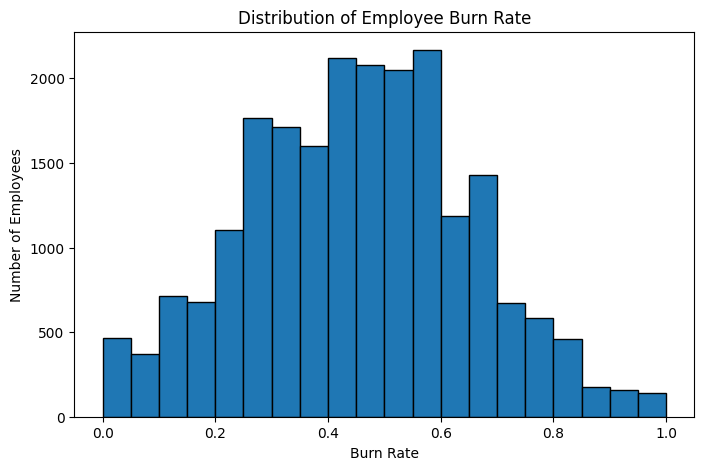

In [473]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df['Burn Rate'], bins=20, edgecolor='black')

plt.xlabel('Burn Rate')
plt.ylabel('Number of Employees')
plt.title('Distribution of Employee Burn Rate')

plt.show()

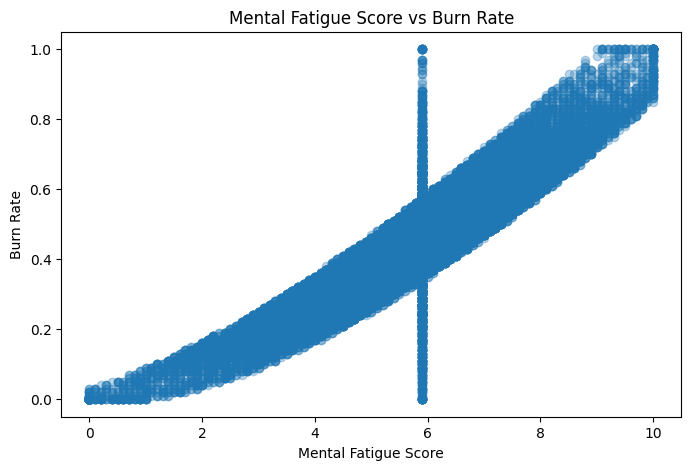

In [474]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    df['Mental Fatigue Score'],
    df['Burn Rate'],
    alpha=0.3
)

plt.xlabel('Mental Fatigue Score')
plt.ylabel('Burn Rate')
plt.title('Mental Fatigue Score vs Burn Rate')

plt.show()

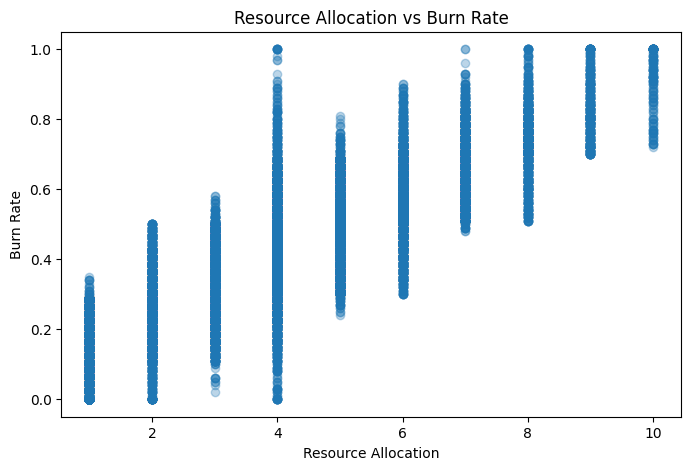

In [475]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    df['Resource Allocation'],
    df['Burn Rate'],
    alpha=0.3
)

plt.xlabel('Resource Allocation')
plt.ylabel('Burn Rate')
plt.title('Resource Allocation vs Burn Rate')

plt.show()

Average Burn Rate by WFH Setup:
WFH Setup Available
No     0.517824
Yes    0.396010
Name: Burn Rate, dtype: float64


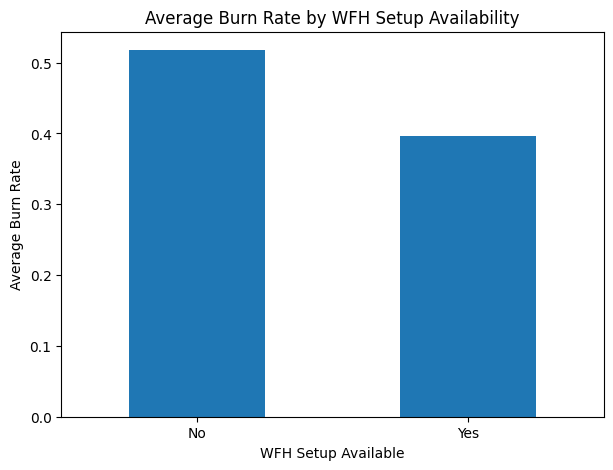

In [476]:
wfh_burnout = df.groupby('WFH Setup Available')['Burn Rate'].mean()

print("Average Burn Rate by WFH Setup:")
print(wfh_burnout)

wfh_burnout.plot(kind='bar', figsize=(7, 5))

plt.xlabel('WFH Setup Available')
plt.ylabel('Average Burn Rate')
plt.title('Average Burn Rate by WFH Setup Availability')
plt.xticks(rotation=0)
plt.show()

Average Burn Rate by Gender:
Gender
Female    0.422788
Male      0.484271
Name: Burn Rate, dtype: float64


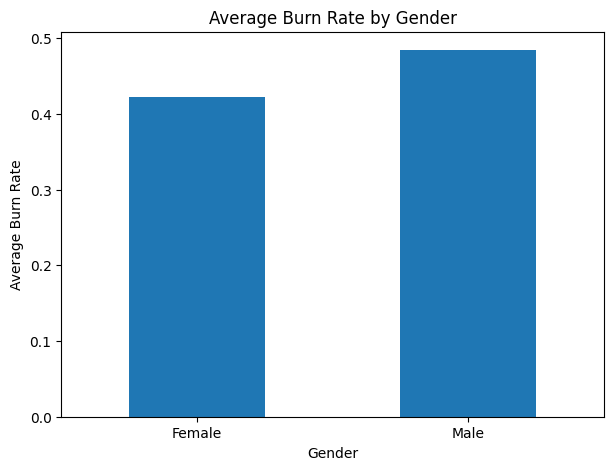

In [477]:
gender_burnout = df.groupby('Gender')['Burn Rate'].mean()

print("Average Burn Rate by Gender:")
print(gender_burnout)

gender_burnout.plot(kind='bar', figsize=(7, 5))

plt.xlabel('Gender')
plt.ylabel('Average Burn Rate')
plt.title('Average Burn Rate by Gender')
plt.xticks(rotation=0)
plt.show()

Average Burn Rate by Company Type:
Company Type
Product    0.450841
Service    0.452624
Name: Burn Rate, dtype: float64


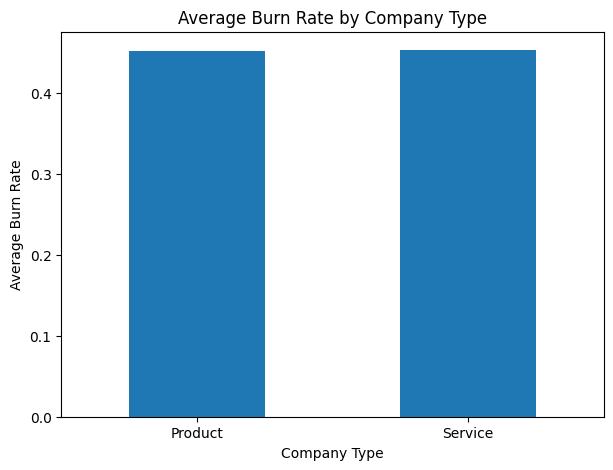

In [478]:
company_burnout = df.groupby('Company Type')['Burn Rate'].mean()

print("Average Burn Rate by Company Type:")
print(company_burnout)

company_burnout.plot(kind='bar', figsize=(7, 5))

plt.xlabel('Company Type')
plt.ylabel('Average Burn Rate')
plt.title('Average Burn Rate by Company Type')
plt.xticks(rotation=0)
plt.show()

Correlation Matrix:
                      Designation  Resource Allocation  Mental Fatigue Score  \
Designation              1.000000             0.851383              0.657882   
Resource Allocation      0.851383             1.000000              0.740061   
Mental Fatigue Score     0.657882             0.740061              1.000000   
Burn Rate                0.737556             0.829632              0.898926   

                      Burn Rate  
Designation            0.737556  
Resource Allocation    0.829632  
Mental Fatigue Score   0.898926  
Burn Rate              1.000000  


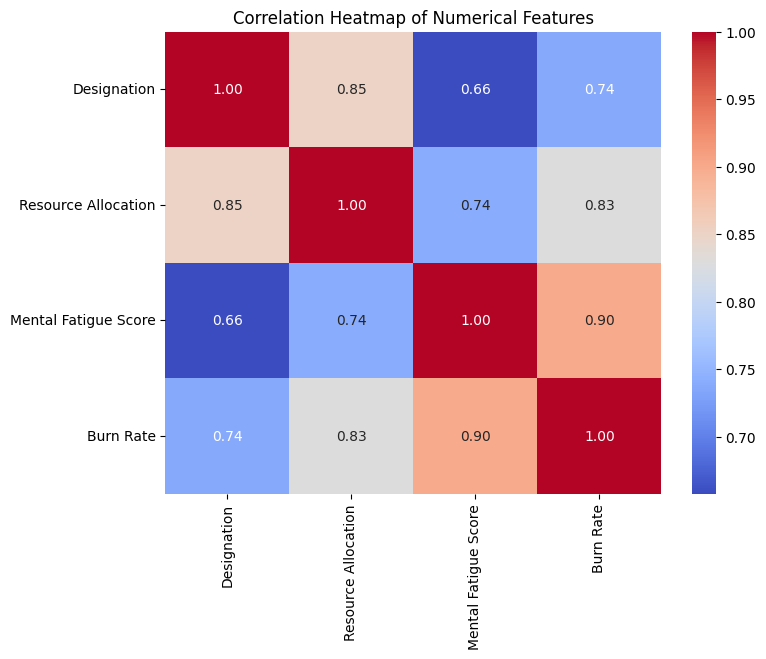

In [479]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_columns = [
    'Designation',
    'Resource Allocation',
    'Mental Fatigue Score',
    'Burn Rate'
]

# Calculate correlation
correlation_matrix = df[numerical_columns].corr()

# Print correlation values
print("Correlation Matrix:")
print(correlation_matrix)

# Create heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [480]:
# Remove Employee ID because it is only a unique identifier
df = df.drop(columns=['Employee ID'])

print("Columns after removing Employee ID:")
print(df.columns.tolist())

Columns after removing Employee ID:
['Date of Joining', 'Gender', 'Company Type', 'WFH Setup Available', 'Designation', 'Resource Allocation', 'Mental Fatigue Score', 'Burn Rate']


In [481]:
# Convert Date of Joining from text to datetime format
df['Date of Joining'] = pd.to_datetime(df['Date of Joining'])

# Check the earliest and latest joining dates
print("Earliest Joining Date:", df['Date of Joining'].min())
print("Latest Joining Date:", df['Date of Joining'].max())

# Display first 5 dates
print("\nSample Joining Dates:")
print(df['Date of Joining'].head())

Earliest Joining Date: 2008-01-01 00:00:00
Latest Joining Date: 2008-12-31 00:00:00

Sample Joining Dates:
0   2008-09-30
1   2008-11-30
2   2008-03-10
3   2008-11-03
4   2008-07-24
Name: Date of Joining, dtype: datetime64[ns]


In [482]:
# Drop Date of Joining
df = df.drop(columns=['Date of Joining'])

print("Remaining Columns:")
print(df.columns.tolist())

Remaining Columns:
['Gender', 'Company Type', 'WFH Setup Available', 'Designation', 'Resource Allocation', 'Mental Fatigue Score', 'Burn Rate']


In [483]:
# Convert categorical columns into numerical columns using one-hot encoding
df = pd.get_dummies(
    df,
    columns=['Gender', 'Company Type', 'WFH Setup Available'],
    drop_first=True,
    dtype=int
)

# Display the first 5 rows
print(df.head())

# Display updated column names
print("\nColumns after encoding:")
print(df.columns.tolist())

   Designation  Resource Allocation  Mental Fatigue Score  Burn Rate  \
0            2                  3.0                   3.8       0.16   
1            1                  2.0                   5.0       0.36   
2            2                  4.0                   5.8       0.49   
3            1                  1.0                   2.6       0.20   
4            3                  7.0                   6.9       0.52   

   Gender_Male  Company Type_Service  WFH Setup Available_Yes  
0            0                     1                        0  
1            1                     1                        1  
2            0                     0                        1  
3            1                     1                        1  
4            0                     1                        0  

Columns after encoding:
['Designation', 'Resource Allocation', 'Mental Fatigue Score', 'Burn Rate', 'Gender_Male', 'Company Type_Service', 'WFH Setup Available_Yes']


In [484]:
# X contains the input features
X = df.drop(columns=['Burn Rate'])

# y contains the target we want to predict
y = df['Burn Rate']

print("X Shape:", X.shape)
print("y Shape:", y.shape)

print("\nInput Features:")
print(X.columns.tolist())


X Shape: (21626, 6)
y Shape: (21626,)

Input Features:
['Designation', 'Resource Allocation', 'Mental Fatigue Score', 'Gender_Male', 'Company Type_Service', 'WFH Setup Available_Yes']


In [485]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (17300, 6)
X_test Shape: (4326, 6)
y_train Shape: (17300,)
y_test Shape: (4326,)


In [486]:
from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

# Make predictions on test data
y_pred_linear = linear_model.predict(X_test)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [487]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred_linear)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression Results:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

Linear Regression Results:
MAE: 0.05346091183717166
RMSE: 0.07092672584227555
R² Score: 0.8679230827173483


In [488]:
from sklearn.ensemble import RandomForestRegressor

# Create the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model using training data
rf_model.fit(X_train, y_train)

# Predict Burn Rate for test data
y_pred_rf = rf_model.predict(X_test)

# Evaluate Random Forest
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Results:")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Results:
MAE: 0.049604312149417885
RMSE: 0.06424060272164962
R² Score: 0.8916506492340128


In [489]:
from sklearn.ensemble import GradientBoostingRegressor

# Create the Gradient Boosting model
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
gb_model.fit(X_train, y_train)

# Predict Burn Rate for test data
y_pred_gb = gb_model.predict(X_test)

# Evaluate Gradient Boosting
gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_r2 = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Results:")
print("MAE:", gb_mae)
print("RMSE:", gb_rmse)
print("R² Score:", gb_r2)

Gradient Boosting Results:
MAE: 0.048317100166280644
RMSE: 0.061752213268106614
R² Score: 0.8998820023750832


In [490]:
# Create a comparison table for all three models
model_comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'MAE': [
        mae,
        rf_mae,
        gb_mae
    ],
    'RMSE': [
        rmse,
        rf_rmse,
        gb_rmse
    ],
    'R2 Score': [
        r2,
        rf_r2,
        gb_r2
    ]
})

print(model_comparison)

               Model       MAE      RMSE  R2 Score
0  Linear Regression  0.053461  0.070927  0.867923
1      Random Forest  0.049604  0.064241  0.891651
2  Gradient Boosting  0.048317  0.061752  0.899882


In [491]:
from sklearn.ensemble import ExtraTreesRegressor

# Create Extra Trees model
et_model = ExtraTreesRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
et_model.fit(X_train, y_train)

# Make predictions
y_pred_et = et_model.predict(X_test)

# Evaluate the model
et_mae = mean_absolute_error(y_test, y_pred_et)
et_rmse = np.sqrt(mean_squared_error(y_test, y_pred_et))
et_r2 = r2_score(y_test, y_pred_et)

print("Extra Trees Results:")
print("MAE:", et_mae)
print("RMSE:", et_rmse)
print("R² Score:", et_r2)

Extra Trees Results:
MAE: 0.050977317556150974
RMSE: 0.06618711515899647
R² Score: 0.8849851270545608


In [492]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Perform 5-fold cross-validation on training data
cv_scores = cross_val_score(
    gb_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("R² Score for each fold:")
print(cv_scores)

print("\nAverage Cross-Validation R²:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

R² Score for each fold:
[0.89963432 0.90623066 0.90472956 0.8959714  0.90668919]

Average Cross-Validation R²: 0.9026510252027069
Standard Deviation: 0.004175137227467816


In [493]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

# Different settings we want to test
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3, 4]
}

# Create Gradient Boosting model
gb_tuning_model = GradientBoostingRegressor(random_state=42)

# Try different combinations using 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=gb_tuning_model,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Find the best settings using training data
grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation R²:")
print(grid_search.best_score_)

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}

Best Cross-Validation R²:
0.9077066274040002


In [494]:
# Get the best tuned Gradient Boosting model
best_gb_model = grid_search.best_estimator_

# Predict on the test data
y_pred_tuned = best_gb_model.predict(X_test)

# Calculate final evaluation metrics
tuned_mae = mean_absolute_error(y_test, y_pred_tuned)
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
tuned_r2 = r2_score(y_test, y_pred_tuned)

print("Tuned Gradient Boosting Results:")
print("MAE:", tuned_mae)
print("RMSE:", tuned_rmse)
print("R² Score:", tuned_r2)

Tuned Gradient Boosting Results:
MAE: 0.04697168793992462
RMSE: 0.059854954248813826
R² Score: 0.9059394950620708


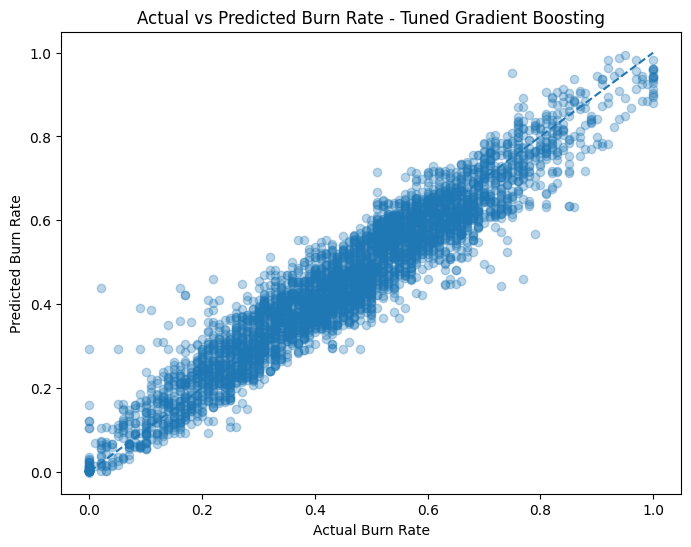

In [495]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Plot actual values vs predictions from tuned model
plt.scatter(y_test, y_pred_tuned, alpha=0.3)

# Perfect prediction reference line
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('Actual Burn Rate')
plt.ylabel('Predicted Burn Rate')
plt.title('Actual vs Predicted Burn Rate - Tuned Gradient Boosting')

plt.show()

In [496]:
# Create new employee data
new_employee = pd.DataFrame({
    'Designation': [3],
    'Resource Allocation': [7.0],
    'Mental Fatigue Score': [8.0],
    'Gender_Male': [1],
    'Company Type_Service': [1],
    'WFH Setup Available_Yes': [1]
})

# Predict Burn Rate using the final tuned model
predicted_burn_rate = best_gb_model.predict(new_employee)

print("Predicted Burn Rate:", predicted_burn_rate[0])


Predicted Burn Rate: 0.7076255740742106


In [497]:
import joblib

# Save the final tuned Gradient Boosting model
joblib.dump(best_gb_model, 'employee_burnout_model.pkl')

print("Model saved successfully!")

Model saved successfully!
